In [1]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, average_precision_score
from pyod.utils.data import precision_n_scores
from pyod.models.iforest import IForest
from sklearn.ensemble import AdaBoostClassifier

In [2]:
!pip -q install lime

import lime
import lime.lime_tabular

In [3]:
def evaluate_metrics(y_test, y_pred, y_proba=None, digits=3):
    res = {"Accuracy": round(accuracy_score(y_test, y_pred), digits),
           "Precision": round(precision_score(y_test, y_pred), digits),
           "Recall": round(recall_score(y_test, y_pred), digits),
           "F1": round(f1_score(y_test, y_pred), digits),
           "MCC": round(matthews_corrcoef(y_test, y_pred), ndigits=digits)}
    if y_proba is not None:
        res["AUC_PR"] = round(average_precision_score(y_test, y_proba), digits)
        res["AUC_ROC"] = round(roc_auc_score(y_test, y_proba), digits)
        res["PREC_N_SCORES"] = round(precision_n_scores(y_test, y_proba), digits)
    return res


def set_seed_numpy(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

In [4]:
features = [
    "mean", "var", "std", "len", "duration", "len_weighted", "gaps_squared", "n_peaks",
    "smooth10_n_peaks", "smooth20_n_peaks", "var_div_duration", "var_div_len",
    "diff_peaks", "diff2_peaks", "diff_var", "diff2_var", "kurtosis", "skew",
]
SEED = 2137

In [5]:
df = pd.read_csv("data/dataset.csv", index_col="segment")

X_train, y_train = df.loc[df.train==1, features], df.loc[df.train==1, "anomaly"]
X_test, y_test = df.loc[df.train==0, features], df.loc[df.train==0, "anomaly"]
X_train_nominal = df.loc[(df.anomaly==0)&(df.train==1), features]

prep = StandardScaler()
X_train_nominal2 = prep.fit_transform(X_train_nominal)
X_train2 = prep.transform(X_train)
X_test2 = prep.transform(X_test)

In [6]:
set_seed_numpy(SEED)

In [7]:
# supervised example 

In [8]:
model = AdaBoostClassifier(random_state=SEED)
model.fit(X_train2, y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

AdaBoostClassifier(random_state=2137) 
 {'Accuracy': 0.934, 'Precision': 0.89, 'Recall': 0.788, 'F1': 0.836, 'MCC': 0.797, 'AUC_PR': 0.923, 'AUC_ROC': 0.962, 'PREC_N_SCORES': 0.841}


In [9]:
#LIME explainer (supervised)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train2),
    feature_names=features,
    class_names=["normal", "anomaly"],
    mode="classification",
    discretize_continuous=True
)
#pick an instance to explain
i = 0 #change this index to explain another instance
x = X_test2[i]
true_label = int(y_test.iloc[i])

#AdaBoost supports predict_proba
exp = explainer.explain_instance(
    data_row=x,
    predict_fn=model.predict_proba,
    num_features=18
)
print("True label:", true_label)
print("Pred probs [normal, anomaly]:", model.predict_proba([x])[0])

print(exp.as_list())




True label: 0
Pred probs [normal, anomaly]: [0.53466724 0.46533276]
[('smooth10_n_peaks <= -0.06', -0.02352197476879771), ('len > 0.60', 0.021625566513838946), ('diff2_peaks > 0.11', -0.018706852112998593), ('diff2_var <= -0.42', -0.015127161634180555), ('diff_peaks > 0.01', -0.013010161590912384), ('n_peaks <= -0.13', -0.010834441254700044), ('-0.18 < duration <= 0.47', 0.005968834215607654), ('kurtosis <= -0.58', -0.0057697671476351926), ('var_div_len <= -0.53', 0.0048816846360069), ('-0.60 < var <= -0.60', 0.003609532309147647), ('-0.60 < var_div_duration <= -0.60', 0.002617866170287458), ('-0.16 < len_weighted <= 0.43', 0.0021343460287816312), ('-0.62 < skew <= -0.35', -0.001508763773068676), ('smooth20_n_peaks <= -0.40', -0.0011417222380697934), ('diff_var <= -0.44', 0.0009558022310560212), ('-0.60 < mean <= 0.39', 0.0005429662008865762), ('-0.70 < std <= -0.70', -0.00033706583274323976), ('gaps_squared <= -0.71', -0.00013648707575828042)]


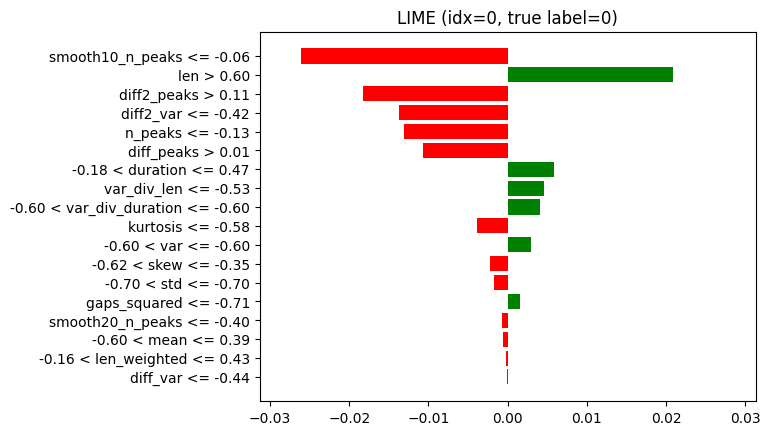

In [10]:
import matplotlib.pyplot as plt
for i in [0]: #change these indices to explain other instances
    exp_i = explainer.explain_instance(X_test2[i], model.predict_proba, num_features=18)

    weights = [w for _, w in exp_i.as_list()]
    max_val = max(abs(w) for w in weights)
    fig = exp_i.as_pyplot_figure(label=1)
    ax = plt.gca()
    ax.set_xlim(-max_val*1.2, max_val*1.2)
    plt.title(f"LIME (idx={i}, true label={y_test.iloc[i]})")
    plt.show()


In [11]:
# unsupervised example

In [12]:
model = IForest(random_state=SEED)
model.fit(X_train2)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.766, 'Precision': 0.4, 'Recall': 0.195, 'F1': 0.262, 'MCC': 0.155, 'AUC_PR': 0.347, 'AUC_ROC': 0.635, 'PREC_N_SCORES': 0.301}


In [13]:
import lime
import lime.lime_tabular
from IPython.display import display, HTML
# 1. Define the prediction function for LIME
# LIME requires a function that takes a numpy array (n_samples, n_features)
# and returns a numpy array (n_samples, n_classes) of prediction probabilities.
# The PyOD IForest model's `predict_proba` method does this perfectly.
predict_fn = lambda x: model.predict_proba(x)

# 2. Create the LIME Explainer
# We use the scaled training data (X_train2) to initialize the explainer.
# This helps LIME generate meaningful perturbations.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train2,
    feature_names=features,
    class_names=['Normal', 'Anomaly'],
    mode='classification',
    # Using quartiles for discretization is a good default
    discretize_continuous=True
)





EXPLANATION FOR INDEX: 13
True label: 0
Pred probs [Normal, Anomaly]: [0.529415 0.470585]
[('smooth20_n_peaks <= -0.40', -0.007544039133260995), ('n_peaks <= -0.13', -0.007098663347247639), ('smooth10_n_peaks <= -0.06', -0.006958804482521196), ('diff_peaks > 0.01', 0.00661131413350835), ('diff2_peaks > 0.11', 0.005019425495298201), ('kurtosis > 0.50', 0.004760258594889398), ('-0.42 < diff2_var <= -0.42', -0.003946614281094843), ('diff_var <= -0.44', -0.0038407395935823206), ('-0.53 < var_div_len <= -0.53', -0.0028920133136939594), ('-0.60 < var <= -0.60', -0.0028539436219535506), ('-0.60 < var_div_duration <= -0.60', -0.002324971658534823), ('-0.70 < std <= -0.70', -0.0018974203236175873), ('-0.48 < duration <= -0.18', -0.0014669098611739234), ('-0.49 < len_weighted <= -0.16', -0.0014398925668719536), ('gaps_squared <= -0.71', -0.0009857969112736268), ('-0.60 < mean <= 0.39', -0.0008639789148403686), ('skew <= -0.62', 0.000530909699132897), ('-0.40 < len <= 0.60', -0.0005197100055891

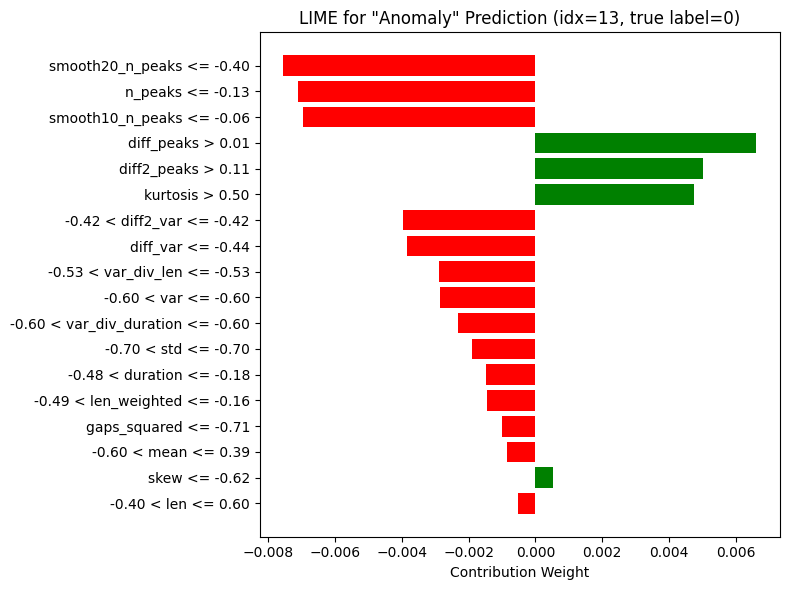

In [14]:
#  LIME EXPLANATION FOR ISOLATION FOREST 


import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# CHOOSE THE INSTANCE YOU WANT TO EXPLAIN
i = 13  # <--  CHANGE THIS NUMBER 

#  Helper functions  
def print_simple_text_explanation(explanation, instance_data, predict_fn, y_test, instance_index, class_names, label_to_explain):
    true_label = int(y_test.iloc[instance_index])
    print(f"True label: {true_label}")
    probs = predict_fn(np.array([instance_data]))[0]
    print(f"Pred probs [{class_names[0]}, {class_names[1]}]: {probs}")
    exp_list = explanation.as_list(label=label_to_explain)
    print(exp_list)

def plot_lime_explanation(explanation, instance_idx, true_label, label_to_explain, class_names):
    exp_list = explanation.as_list(label=label_to_explain)
    exp_list.reverse()
    vals = [x[1] for x in exp_list]; names = [x[0] for x in exp_list]
    colors = ['green' if x > 0 else 'red' for x in vals]
    fig, ax = plt.subplots(figsize=(8, 6)); y_pos = np.arange(len(names))
    ax.barh(y_pos, vals, color=colors); ax.set_yticks(y_pos); ax.set_yticklabels(names)
    ax.set_title(f'LIME for "{class_names[label_to_explain]}" Prediction (idx={instance_idx}, true label={true_label})')
    ax.set_xlabel('Contribution Weight'); plt.tight_layout(); plt.show()


#  Main execution logic 
class_names_list = ['Normal', 'Anomaly']

# 1. Setup the explainer
def predict_fn(x):
    scores = model.decision_function(x)
    # Convert decision function output to probability-like values
    probs_anomaly = 1 / (1 + np.exp(-scores))
    probs_normal = 1 - probs_anomaly
    return np.vstack((probs_normal, probs_anomaly)).T

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train2, feature_names=features, class_names=class_names_list,
    mode='classification', discretize_continuous=True
)

# 2. Check if the chosen index is valid
if i not in y_test.index:
    print(f"Error: Index {i} is not in the test set. Please choose a valid index.")
else:
    # 3. Get the data for the chosen index
    instance_to_explain_scaled = X_test2[i]
    true_label = int(y_test.iloc[i])
    
    # 4. Generate the explanation
    explanation = explainer.explain_instance(
        data_row=instance_to_explain_scaled,
        predict_fn=predict_fn,
        num_features=18,
        labels=(0, 1)
    )
    
    # 5. Get the model's actual prediction to dynamically set the plot title
    raw_pred = model.predict(np.array([instance_to_explain_scaled]))[0]
    prediction = 0 if raw_pred == 1 else 1  # IForest returns
    
    # 6. Display the outputs
    print("\n")
    print(f"EXPLANATION FOR INDEX: {i}")
   
    print_simple_text_explanation(explanation, instance_to_explain_scaled, predict_fn, y_test, i, class_names_list, prediction)
    plot_lime_explanation(explanation, i, true_label, prediction, class_names_list)


In [15]:
model = IForest(random_state=SEED, contamination=.2)
model.fit(X_train2)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))


IForest(behaviour='old', bootstrap=False, contamination=0.2, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.701, 'Precision': 0.297, 'Recall': 0.292, 'F1': 0.295, 'MCC': 0.105, 'AUC_PR': 0.347, 'AUC_ROC': 0.635, 'PREC_N_SCORES': 0.301}




EXPLANATION FOR INDEX: 13
True label: 0
Pred probs [Normal, Anomaly]: [0.51965483 0.48034517]
[('smooth10_n_peaks <= -0.06', -0.007918734875813413), ('n_peaks <= -0.13', -0.007397162300826767), ('smooth20_n_peaks <= -0.40', -0.006885212190410544), ('diff_peaks > 0.01', 0.005994854692046952), ('kurtosis > 0.50', 0.0044801103667164045), ('diff2_peaks > 0.11', 0.00446086246904585), ('-0.42 < diff2_var <= -0.42', -0.003947663206754106), ('-0.60 < var <= -0.60', -0.0035314162311442274), ('-0.70 < std <= -0.70', -0.0028887621340701365), ('-0.53 < var_div_len <= -0.53', -0.0028028784801436826), ('diff_var <= -0.44', -0.0027719433956802982), ('-0.60 < var_div_duration <= -0.60', -0.0025529622804765445), ('-0.48 < duration <= -0.18', -0.0013434021109937223), ('gaps_squared <= -0.71', -0.001125048188761545), ('skew <= -0.62', 0.0008857010932685035), ('-0.40 < len <= 0.60', -0.0008423535044669013), ('-0.49 < len_weighted <= -0.16', -0.0008080511738220147), ('-0.60 < mean <= 0.39', -0.0006418970

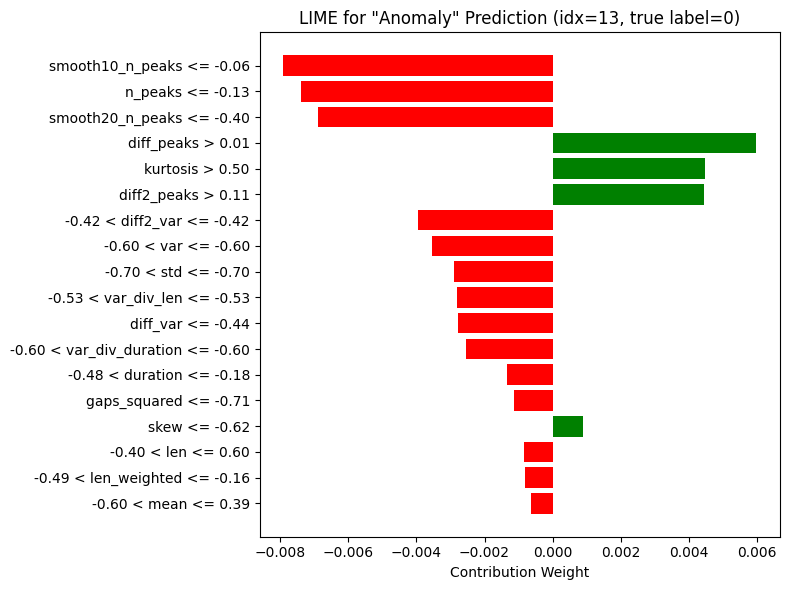

In [16]:
#  LIME EXPLANATION FOR ISOLATION FOREST 


import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# CHOOSE THE INSTANCE YOU WANT TO EXPLAIN
i = 13  # <--  CHANGE THIS NUMBER 

#  Helper functions (no changes needed here) 
def print_simple_text_explanation(explanation, instance_data, predict_fn, y_test, instance_index, class_names, label_to_explain):
    true_label = int(y_test.iloc[instance_index])
    print(f"True label: {true_label}")
    probs = predict_fn(np.array([instance_data]))[0]
    print(f"Pred probs [{class_names[0]}, {class_names[1]}]: {probs}")
    exp_list = explanation.as_list(label=label_to_explain)
    print(exp_list)

def plot_lime_explanation(explanation, instance_idx, true_label, label_to_explain, class_names):
    exp_list = explanation.as_list(label=label_to_explain)
    exp_list.reverse()
    vals = [x[1] for x in exp_list]; names = [x[0] for x in exp_list]
    colors = ['green' if x > 0 else 'red' for x in vals]
    fig, ax = plt.subplots(figsize=(8, 6)); y_pos = np.arange(len(names))
    ax.barh(y_pos, vals, color=colors); ax.set_yticks(y_pos); ax.set_yticklabels(names)
    ax.set_title(f'LIME for "{class_names[label_to_explain]}" Prediction (idx={instance_idx}, true label={true_label})')
    ax.set_xlabel('Contribution Weight'); plt.tight_layout(); plt.show()


#  Main execution logic 
class_names_list = ['Normal', 'Anomaly']

# 1. Setup the explainer
def predict_fn(x):
    scores = model.decision_function(x)
    # Convert decision function output to probability-like values
    probs_anomaly = 1 / (1 + np.exp(-scores))
    probs_normal = 1 - probs_anomaly
    return np.vstack((probs_normal, probs_anomaly)).T

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train2, feature_names=features, class_names=class_names_list,
    mode='classification', discretize_continuous=True
)

# 2. Check if the chosen index is valid
if i not in y_test.index:
    print(f"Error: Index {i} is not in the test set. Please choose a valid index.")
else:
    # 3. Get the data for the chosen index
    instance_to_explain_scaled = X_test2[i]
    true_label = int(y_test.iloc[i])
    
    # 4. Generate the explanation
    explanation = explainer.explain_instance(
        data_row=instance_to_explain_scaled,
        predict_fn=predict_fn,
        num_features=18,
        labels=(0, 1)
    )
    
    # 5. Get the model's actual prediction to dynamically set the plot title
    raw_pred = model.predict(np.array([instance_to_explain_scaled]))[0]
    prediction = 0 if raw_pred == 1 else 1  # IForest returns
    
    # 6. Display the outputs
    print("\n")
    print(f"EXPLANATION FOR INDEX: {i}")
   
    print_simple_text_explanation(explanation, instance_to_explain_scaled, predict_fn, y_test, i, class_names_list, prediction)
    plot_lime_explanation(explanation, i, true_label, prediction, class_names_list)
